In [1]:
import json

DATA_INFO_PATH = "SLEEP/dataset_info.json"

with open(DATA_INFO_PATH, "r", encoding="utf-8") as f:
    info = json.load(f)

category_list = info["dataset"]["category_list"]
channels = info["dataset"]["channels"]
target_sampling_rate = info["processing"]["target_sampling_rate"]
window_sec = info["processing"]["window_sec"]

print("=== Dataset Intro ===")
print("Categories:", category_list)
print("Channels (count):", len(channels))
print("Channels:", channels)
print("Target Sampling Rate (Hz):", target_sampling_rate)
print("Window Size (sec):", window_sec)


=== Dataset Intro ===
Categories: ['Wake', 'N1', 'N2', 'N3', 'REM']
Channels (count): 6
Channels: ['C3_A2', 'C4_A1', 'F3_A2', 'F4_A1', 'O1_A2', 'O2_A1']
Target Sampling Rate (Hz): 200.0
Window Size (sec): 30.0


## 1) 设定数据路径并检查数据形状
这一格会选择数据集（`DATA_NAME`），并读取 `train/val/test` 的基本信息，先确认维度是否符合预期。


In [2]:
import h5py
import numpy as np
DATA_NAME = "SLEEP"
INDEX_PATH_TRAIN = f"{DATA_NAME}/train.h5"
INDEX_PATH_VAL = f"{DATA_NAME}/val.h5"
INDEX_PATH_TEST = f"{DATA_NAME}/test_x_only.h5"

with h5py.File(INDEX_PATH_TRAIN, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))

keys: ['X', 'y']
x dtype: float32
x shape: (3921, 6, 6000)
y dtype: int64
y shape: (3921,)
unique: [0 1 2 3 4]


## 5) 导入模型
这里希望同学们自己手搓一个RNN代码，试试RNN的训练效果如何


In [3]:

from MultiScaleDeepSleepNet import MultiScaleDeepSleepNet

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
        # 将 alpha 注册为 buffer，这样它会随模型一起移动到 GPU/CPU
        if alpha is not None:
            self.register_buffer('alpha', alpha)
        else:
            self.alpha = None

    def forward(self, inputs, targets):
        # 这里的 self.alpha 会自动与 inputs 在同一设备上
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

## 6) 准备 DataLoader 并训练/验证
这一格完成数据加载、损失函数与优化器设置，然后执行训练循环并记录 `train/val` 指标与曲线。


Using device: cuda
Channels: 6, Classes: 5
Epoch [01/30] | Train Loss: 1.5336 | Val Loss: 1.4172 | Val Acc: 0.4276
Epoch [02/30] | Train Loss: 1.3615 | Val Loss: 1.2234 | Val Acc: 0.5281
Epoch [03/30] | Train Loss: 1.2618 | Val Loss: 1.3048 | Val Acc: 0.4807
Epoch [04/30] | Train Loss: 1.2624 | Val Loss: 1.2465 | Val Acc: 0.5183
Epoch [05/30] | Train Loss: 1.1939 | Val Loss: 1.1791 | Val Acc: 0.5626
Epoch [06/30] | Train Loss: 1.1863 | Val Loss: 1.2519 | Val Acc: 0.5188
Epoch [07/30] | Train Loss: 1.1459 | Val Loss: 1.1678 | Val Acc: 0.5497
Epoch [08/30] | Train Loss: 1.1224 | Val Loss: 1.1459 | Val Acc: 0.5734
Epoch [09/30] | Train Loss: 1.1238 | Val Loss: 1.1341 | Val Acc: 0.5848
Epoch [10/30] | Train Loss: 1.0810 | Val Loss: 1.1157 | Val Acc: 0.6064
Epoch [11/30] | Train Loss: 1.0825 | Val Loss: 1.0832 | Val Acc: 0.6090
Epoch [12/30] | Train Loss: 1.0566 | Val Loss: 1.1571 | Val Acc: 0.5708
Epoch [13/30] | Train Loss: 1.0603 | Val Loss: 1.0942 | Val Acc: 0.6043
Epoch [14/30] | Train

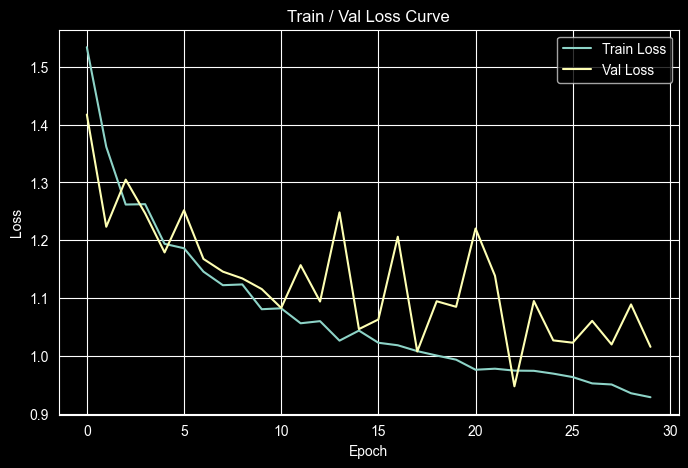

----------------------------------------
Test input shape: torch.Size([1, 6, 6000])
Test output shape: torch.Size([1, 5])


In [27]:
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from TEST_DATASET import TrainDataset, TestDataset


CHANNELS = len(channels)      # 应该是 6: ['C3_A2', 'C4_A1', 'F3_A2', 'F4_A1', 'O1_A2', 'O2_A1']
CLASSES = len(category_list)  # 应该是 5: ['Wake', 'N1', 'N2', 'N3', 'REM']
patch_size = 200
BATCH_SIZE = 64
EPOCHS = 30
LR = 8e-4

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Channels: {CHANNELS}, Classes: {CLASSES}")

torch.cuda.empty_cache()

# -------------------------
# 数据
# -------------------------
train_ds = TrainDataset(INDEX_PATH_TRAIN)
val_ds = TrainDataset(INDEX_PATH_VAL)
test_ds = TestDataset(INDEX_PATH_TEST)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

# -------------------------
# 模型、损失、优化器
# -------------------------
model = MultiScaleDeepSleepNet(
    chans=CHANNELS,
    num_classes=CLASSES,
    hidden_dim=128,
    dropout=0.5 # 睡眠数据容易过拟合，建议 dropout 设大一点
).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 在 train.ipynb 定义优化器后加入
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=7, verbose=True)


# -------------------------
# 记录曲线
# -------------------------
train_losses = []
val_losses = []
val_accuracies = []

# -------------------------
# 训练循环
# -------------------------
for epoch in range(EPOCHS):
    # ===== Train =====
    model.train()
    train_loss_sum = 0.0
    train_num = 0

    for data, label in train_loader:
        data, label = data.to(device), label.to(device)

        optimizer.zero_grad()

        output = model(data)
        loss = criterion(output, label)

        loss.backward()
        model.clip_gradients()
        optimizer.step()

        batch_size = label.size(0)
        train_loss_sum += loss.item() * batch_size
        train_num += batch_size

    epoch_train_loss = train_loss_sum / train_num
    train_losses.append(epoch_train_loss)


    # ===== Val =====
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_num = 0

    with torch.no_grad():
        for val_data, val_label in val_loader:
            val_data, val_label = val_data.to(device), val_label.to(device)
            val_output = model(val_data)
            val_loss = criterion(val_output, val_label)

            batch_size = val_label.size(0)
            val_loss_sum += val_loss.item() * batch_size
            val_num += batch_size

            val_pred = torch.argmax(val_output, dim=1)
            val_correct += (val_pred == val_label).sum().item()

    epoch_val_loss = val_loss_sum / val_num
    epoch_val_acc = val_correct / val_num

    scheduler.step(epoch_val_acc)

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f}"
    )

# -------------------------
# 输出最终 val accuracy
# -------------------------
print("\n" + "-" * 40)
print(f"Final Val Accuracy: {val_accuracies[-1]:.4f}")

# -------------------------
# 画 train / val loss 曲线
# -------------------------
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Val Loss Curve")
plt.legend()
plt.show()


# -------------------------
# test 推理示例
# -------------------------
test_data = next(iter(test_loader))
test_data = test_data.to(device)
test_pred = model(test_data)
print("-" * 40)
print("Test input shape:", test_data.shape)
print("Test output shape:", test_pred.shape)

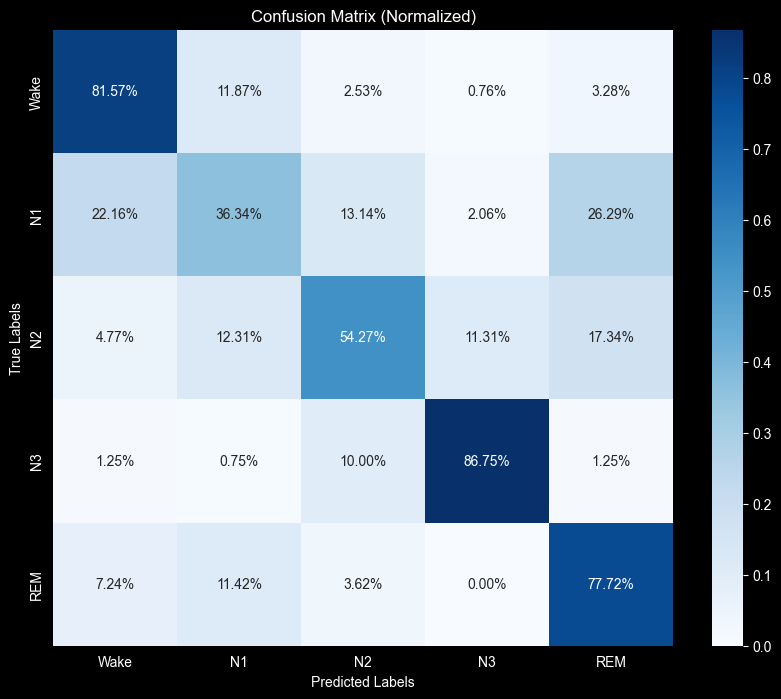

              precision    recall  f1-score   support

        Wake       0.70      0.82      0.76       396
          N1       0.50      0.36      0.42       388
          N2       0.65      0.54      0.59       398
          N3       0.86      0.87      0.86       400
         REM       0.60      0.78      0.67       359

    accuracy                           0.67      1941
   macro avg       0.66      0.67      0.66      1941
weighted avg       0.67      0.67      0.66      1941



In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def plot_confusion_matrix(model, val_loader, device, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data, labels in val_loader:
            data = data.to(device)
            outputs = model(data)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # 1. 计算混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)

    # 2. 归一化（显示百分比，更直观）
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # 3. 绘图
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_percent, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix (Normalized)')
    plt.show()

    # 4. 打印详细报告 (Precision, Recall, F1)
    print(classification_report(all_labels, all_preds, target_names=classes))

# 调用方法（假设你的类别列表如下）
class_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
plot_confusion_matrix(model, val_loader, device, class_names)

## 7) 生成并保存 test 预测标签
使用当前训练好的 `model` 在测试集推理，把预测类别按“每行一个数字”写入文本文件。


In [44]:
# -------------------------
# 保存 test 预测标签 (已修复设备匹配)
# -------------------------
model.eval()
output_path = f'{DATA_NAME}/{DATA_NAME}.txt'

all_test_labels = []
with torch.no_grad():
    for test_data in test_loader:
        # 【关键修正】：将测试数据搬运到 GPU
        test_data = test_data.to(device)

        test_output = model(test_data)
        test_pred = torch.argmax(test_output, dim=1)

        # 【注意】：取出数据存入列表前，必须先 .cpu() 搬回内存
        all_test_labels.extend(test_pred.cpu().tolist())

with open(output_path, "w", encoding="utf-8") as f:
    for label in all_test_labels:
        f.write(f"{int(label)}\n")

print(f"成功保存 {len(all_test_labels)} 条预测结果至: {output_path}")


成功保存 1945 条预测结果至: SLEEP/SLEEP.txt
